# Single-cell RNA-seq trajectory analysis, CPU-friendly end-to-end notebook-style script
## Simulates scRNA-seq counts with NB (Gamma-Poisson) noise, runs Scanpy pipeline,
## performs graph-based pseudotime (DPT) with branching, and builds composite figures.

## Benchmarking rationale:
- Negative binomial models are widely used for droplet scRNA-seq counts and variance structure,
  and droplet scRNA-seq zeros are largely explained without requiring extra zero inflation.
  (Hafemeister & Satija, 2019, Genome Biology, PMID: 31870423),
  (Svensson, 2020, Nature Biotechnology, PMID: 31937974),
  plus trajectory lineage context (Street et al., 2018, BMC Genomics, PMID: 29914354).

## Citations:
- Street, K., et al. (2018). Slingshot: cell lineage and pseudotime inference for single-cell transcriptomics.
  BMC Genomics, 19, 477. https://pubmed.ncbi.nlm.nih.gov/29914354/
- Svensson, V. (2020). Droplet scRNA-seq is not zero-inflated. Nature Biotechnology, 38(2), 147–150.
  https://pubmed.ncbi.nlm.nih.gov/31937974/
- Hafemeister, C., & Satija, R. (2019). Normalization and variance stabilization of single-cell RNA-seq data
  using regularized negative binomial regression. Genome Biology, 20, 296.
  https://pubmed.ncbi.nlm.nih.gov/31870423/

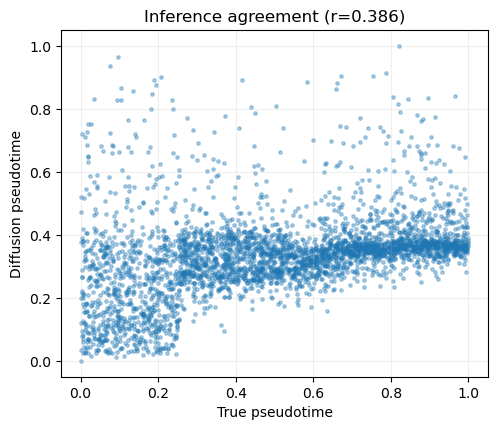

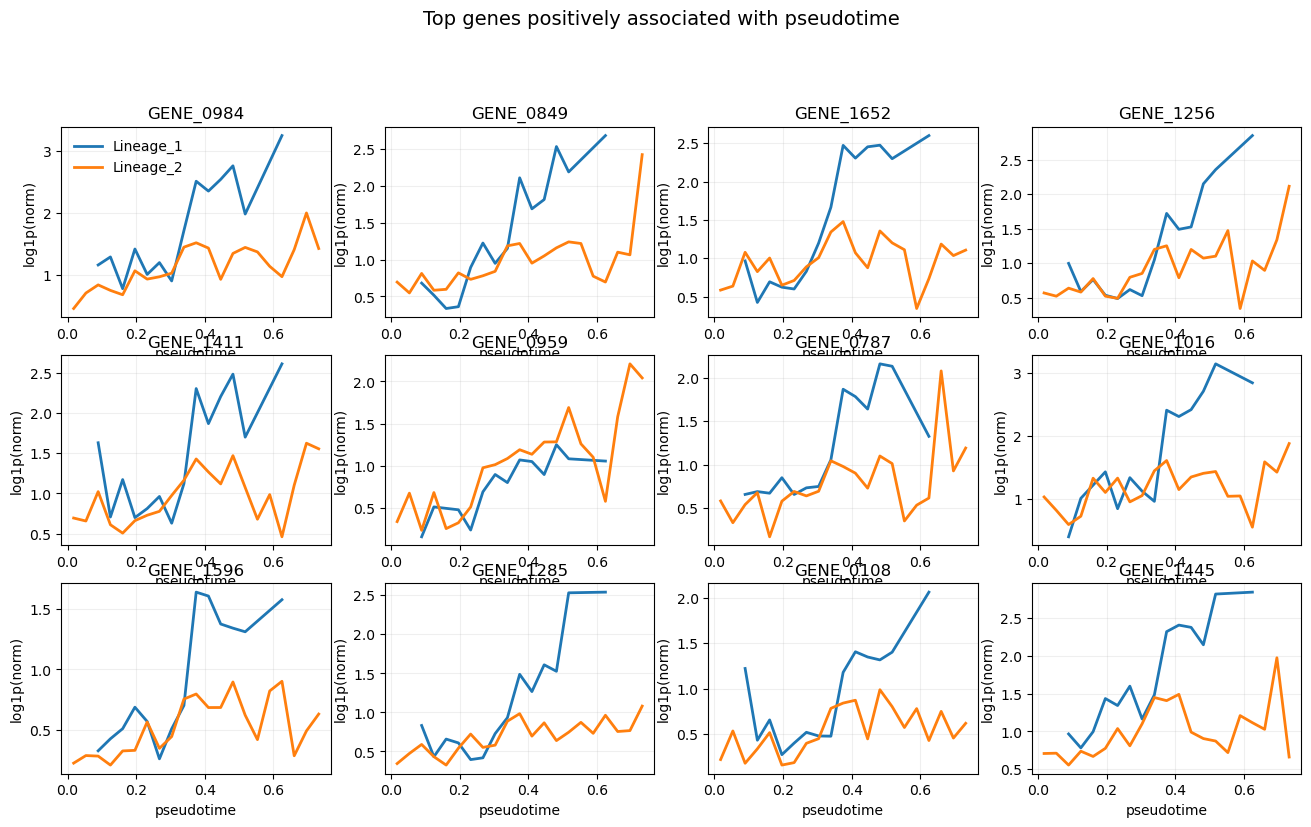

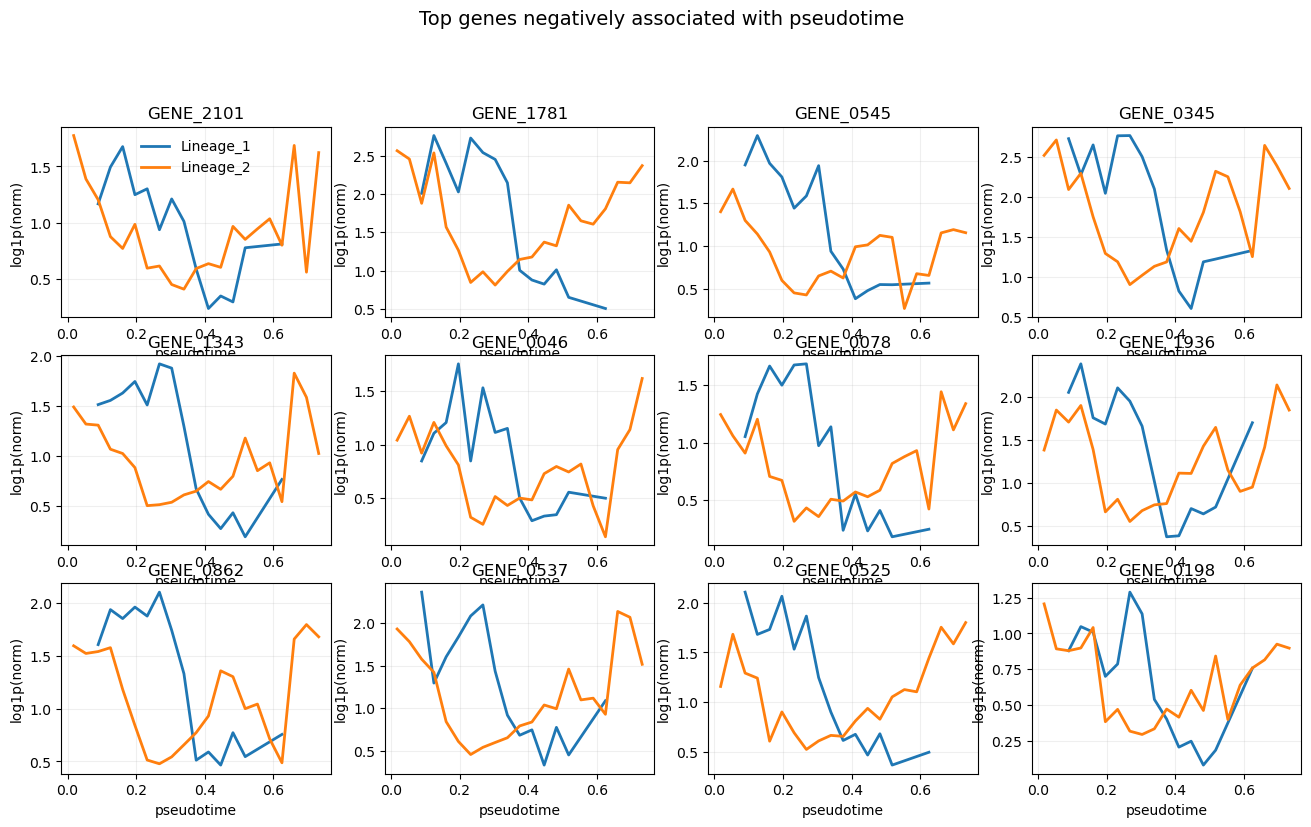

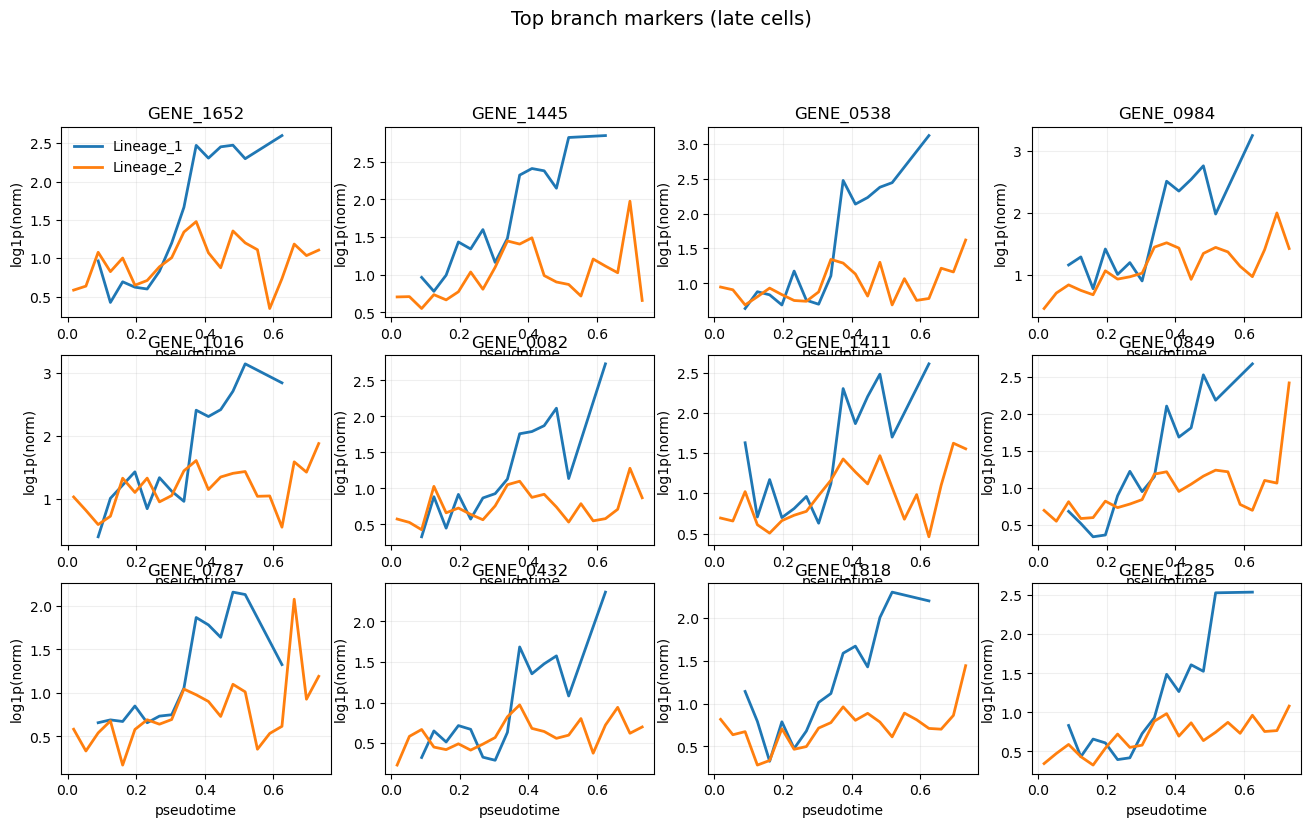

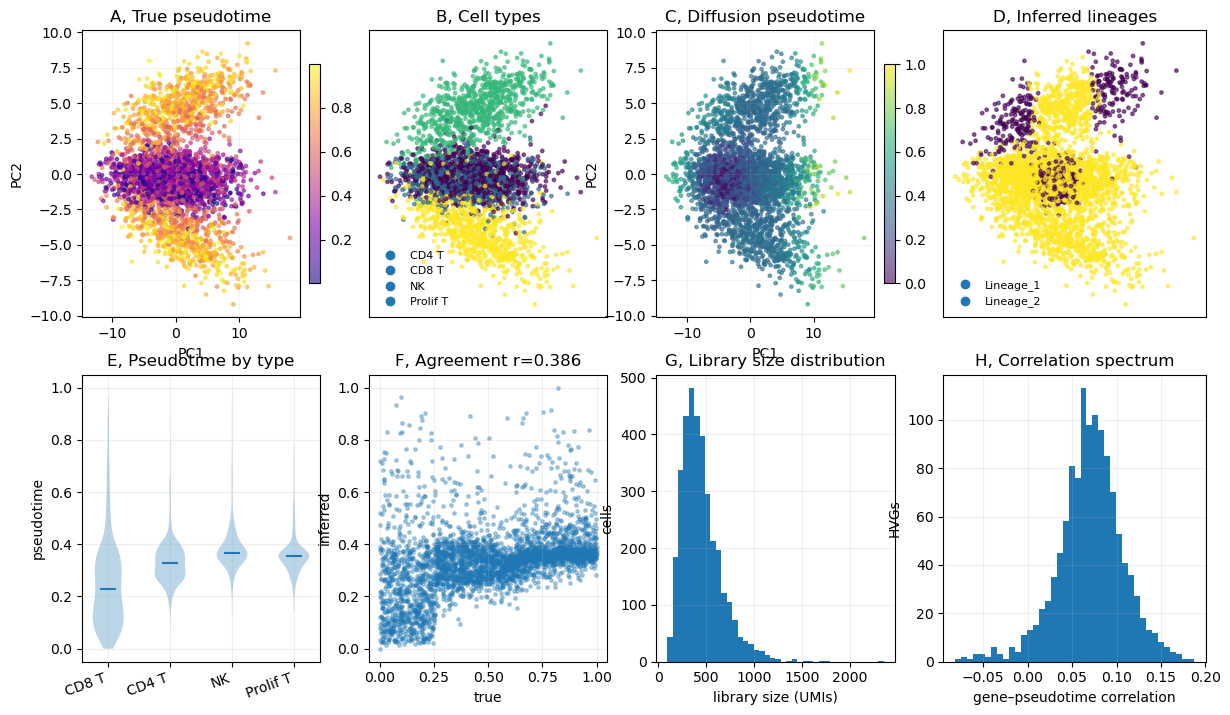

Done.
Outputs:
 - results_trajectory_sim_no_scanpy
Figures: results_trajectory_sim_no_scanpy/figures
Tables: results_trajectory_sim_no_scanpy/tables
Data: results_trajectory_sim_no_scanpy/data


In [25]:
# trajectory analysis without Scanpy (works with NumPy 2.2)
# Simulate droplet scRNA-seq with NB (Gamma-Poisson), build kNN graph, diffusion pseudotime,
# branch assignment, gene association, and composite figures.

import os, json, math
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

OUTDIR = "results_trajectory_sim_no_scanpy"
FIGDIR = os.path.join(OUTDIR, "figures")
TABDIR = os.path.join(OUTDIR, "tables")
DATDIR = os.path.join(OUTDIR, "data")
for d in [OUTDIR, FIGDIR, TABDIR, DATDIR]:
    os.makedirs(d, exist_ok=True)

# journal-indexed benchmarking rationale 
# NB / Gamma-Poisson is a standard model for droplet scRNA-seq count variance structure.
# Droplet scRNA-seq zeros are often not "extra" zero inflation beyond NB expectations.
# Svensson (2020) Nat Biotechnol. https://pubmed.ncbi.nlm.nih.gov/31937974/
# Hafemeister & Satija (2019) Genome Biol. https://pubmed.ncbi.nlm.nih.gov/31870423/
# Slingshot lineage inference reference for conceptual alignment:
# Street et al. (2018) BMC Genomics. https://pubmed.ncbi.nlm.nih.gov/29914354/

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def nb_gamma_poisson(mu, theta, rng):
    mu = np.asarray(mu)
    if np.isscalar(theta):
        theta = np.full(mu.shape[1], float(theta))
    theta = np.asarray(theta).reshape(-1)
    lam = np.empty_like(mu, dtype=float)
    for j in range(mu.shape[1]):
        th = max(theta[j], 1e-6)
        lam[:, j] = rng.gamma(shape=th, scale=np.clip(mu[:, j] / th, 1e-12, None), size=mu.shape[0])
    return rng.poisson(lam).astype(np.int32)

def make_gene_names(n):
    return [f"GENE_{i:04d}" for i in range(n)]

def simulate_branching_scrna(
    n_cells=3500,
    n_genes=2200,
    branch_frac=0.45,
    split_time=0.55,
    umi_target_median=3500,
    umi_target_logsd=0.45,
    theta_gene=18.0,
    rng=None
):
    t = rng.uniform(0, 1, size=n_cells)
    is_post = t >= split_time
    branch = np.array(["pre"] * n_cells, dtype=object)
    branch[is_post] = np.where(rng.uniform(0, 1, is_post.sum()) < branch_frac, "B", "A")

    cell_type = np.empty(n_cells, dtype=object)
    for i in range(n_cells):
        if t[i] < 0.25:
            cell_type[i] = "CD8 T"
        elif t[i] < split_time:
            cell_type[i] = "CD4 T"
        else:
            cell_type[i] = "NK" if branch[i] == "A" else "Prolif T"

    flip = rng.choice(n_cells, size=int(0.05 * n_cells), replace=False)
    for i in flip:
        cell_type[i] = rng.choice(["CD8 T", "CD4 T", "NK", "Prolif T"])

    lib = rng.lognormal(mean=np.log(umi_target_median), sigma=umi_target_logsd, size=n_cells)
    sf = lib / np.median(lib)

    genes = make_gene_names(n_genes)
    idx = np.arange(n_genes)
    rng.shuffle(idx)

    n_house = 250
    n_marker_each = 35
    n_dyn_shared = 180
    n_dyn_branch = 140

    house = idx[:n_house]; p = n_house
    markers = {}
    for ct in ["CD8 T", "CD4 T", "NK", "Prolif T"]:
        markers[ct] = idx[p:p+n_marker_each]; p += n_marker_each
    dyn_shared = idx[p:p+n_dyn_shared]; p += n_dyn_shared
    dyn_A = idx[p:p+n_dyn_branch]; p += n_dyn_branch
    dyn_B = idx[p:p+n_dyn_branch]; p += n_dyn_branch
    rest = idx[p:]

    base = np.zeros(n_genes, dtype=float)
    base[house] = rng.lognormal(mean=np.log(0.8), sigma=0.35, size=house.size)
    base[rest] = rng.lognormal(mean=np.log(0.06), sigma=0.6, size=rest.size)
    for ct in markers:
        base[markers[ct]] = rng.lognormal(mean=np.log(0.12), sigma=0.5, size=markers[ct].size)
    base[dyn_shared] = rng.lognormal(mean=np.log(0.09), sigma=0.45, size=dyn_shared.size)
    base[dyn_A] = rng.lognormal(mean=np.log(0.07), sigma=0.5, size=dyn_A.size)
    base[dyn_B] = rng.lognormal(mean=np.log(0.07), sigma=0.5, size=dyn_B.size)

    mu = np.tile(base.reshape(1, -1), (n_cells, 1))

    inc = dyn_shared[: dyn_shared.size // 2]
    dec = dyn_shared[dyn_shared.size // 2 :]
    act = sigmoid((t - 0.35) / 0.10)
    mu[:, inc] *= (1.0 + act.reshape(-1, 1) * 1.6)
    mu[:, dec] *= (1.0 + (1.0 - act).reshape(-1, 1) * 1.3)

    post_act = sigmoid((t - split_time) / 0.06)
    mu[:, dyn_A] *= (1.0 + (post_act * (branch == "A")).reshape(-1, 1) * 2.0)
    mu[:, dyn_B] *= (1.0 + (post_act * (branch == "B")).reshape(-1, 1) * 2.0)

    prolif_strength = sigmoid((t - 0.72) / 0.07) * (cell_type == "Prolif T").astype(float)
    mu[:, markers["Prolif T"]] *= (1.0 + prolif_strength.reshape(-1, 1) * 4.5)

    nk_strength = sigmoid((t - 0.65) / 0.08) * (cell_type == "NK").astype(float)
    mu[:, markers["NK"]] *= (1.0 + nk_strength.reshape(-1, 1) * 3.5)

    cd8_strength = sigmoid((0.30 - t) / 0.08) * (cell_type == "CD8 T").astype(float)
    mu[:, markers["CD8 T"]] *= (1.0 + cd8_strength.reshape(-1, 1) * 3.0)

    cd4_strength = sigmoid((t - 0.25) / 0.08) * sigmoid((split_time - t) / 0.08) * (cell_type == "CD4 T").astype(float)
    mu[:, markers["CD4 T"]] *= (1.0 + cd4_strength.reshape(-1, 1) * 2.7)

    mu *= sf.reshape(-1, 1)

    theta = np.clip(rng.lognormal(mean=np.log(theta_gene), sigma=0.25, size=n_genes), 3.0, 80.0)
    counts = nb_gamma_poisson(mu, theta, rng)

    obs = pd.DataFrame({
        "cell": [f"CELL_{i:05d}" for i in range(n_cells)],
        "true_pseudotime": t,
        "true_branch": branch,
        "true_cell_type": cell_type,
        "library_size": counts.sum(axis=1)
    }).set_index("cell")

    var = pd.DataFrame({"gene": genes}).set_index("gene")

    meta = {
        "n_cells": int(n_cells),
        "n_genes": int(n_genes),
        "split_time": float(split_time),
        "branch_frac": float(branch_frac),
        "umi_target_median": float(umi_target_median),
        "umi_target_logsd": float(umi_target_logsd),
        "theta_gene_center": float(theta_gene),
        "rng_seed": int(RNG_SEED),
    }
    with open(os.path.join(DATDIR, "simulation_metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return csr_matrix(counts), obs, var

X_counts, obs, var = simulate_branching_scrna(rng=rng)

# Save raw
sparse.save_npz(os.path.join(DATDIR, "counts_raw.npz"), X_counts)
obs.to_csv(os.path.join(DATDIR, "obs_raw.csv"))
var.to_csv(os.path.join(DATDIR, "var_raw.csv"))

# Normalization + log1p

lib = np.asarray(X_counts.sum(axis=1)).reshape(-1)
scale = 1e4 / np.clip(lib, 1, None)
X_norm = X_counts.multiply(scale.reshape(-1, 1))
X_log = X_norm.copy()
X_log.data = np.log1p(X_log.data)

# HVG selection, mean-variance trend 

# Compute per-gene mean and variance on log space
X_log_csr = X_log.tocsr()
gene_mean = np.asarray(X_log_csr.mean(axis=0)).reshape(-1)
# variance: E[x^2] - mean^2
gene_sq_mean = np.asarray(X_log_csr.multiply(X_log_csr).mean(axis=0)).reshape(-1)
gene_var = np.clip(gene_sq_mean - gene_mean**2, 0, None)

df_hvg = pd.DataFrame({
    "gene": var.index.values,
    "mean_log1p": gene_mean,
    "var_log1p": gene_var
}).sort_values("var_log1p", ascending=False)

# Pick HVGs among expressed genes
expr_mask = gene_mean > 0.02
df_hvg = df_hvg.loc[expr_mask].copy()
n_hvg = 1200
hvg_genes = df_hvg.head(n_hvg)["gene"].tolist()
df_hvg.to_csv(os.path.join(TABDIR, "gene_mean_variance.csv"), index=False)

gene_to_idx = {g:i for i,g in enumerate(var.index.values)}
hvg_idx = np.array([gene_to_idx[g] for g in hvg_genes], dtype=int)

X_hvg = X_log_csr[:, hvg_idx]

# PCA

X_hvg_dense = X_hvg.toarray()
X_hvg_dense = (X_hvg_dense - X_hvg_dense.mean(axis=0)) / (X_hvg_dense.std(axis=0) + 1e-8)

pca = PCA(n_components=40, random_state=RNG_SEED)
Z = pca.fit_transform(X_hvg_dense)

# kNN graph + diffusion pseudotime (DPT-like)

k = 20
nbrs = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(Z[:, :25])
dist, nn = nbrs.kneighbors(Z[:, :25])

# Build symmetric affinity matrix using adaptive bandwidth
sigma = np.median(dist[:, -1]) + 1e-8
rows, cols, vals = [], [], []
for i in range(nn.shape[0]):
    for j_idx, d in zip(nn[i], dist[i]):
        w = np.exp(-(d**2) / (sigma**2))
        rows.append(i); cols.append(j_idx); vals.append(w)
W = sparse.coo_matrix((vals, (rows, cols)), shape=(Z.shape[0], Z.shape[0])).tocsr()
W = 0.5 * (W + W.T)

# Row-stochastic diffusion operator P = D^{-1} W
d = np.asarray(W.sum(axis=1)).reshape(-1)
Dinv = diags(1.0 / np.clip(d, 1e-12, None))
P = Dinv @ W

# Diffusion components: top eigenvectors of P (largest magnitude)
# Use symmetric normalization for stable eigensolver: S = D^{1/2} P D^{-1/2} = D^{-1/2} W D^{-1/2}
Dhalf_inv = diags(1.0 / np.sqrt(np.clip(d, 1e-12, None)))
S = Dhalf_inv @ W @ Dhalf_inv

n_eigs = 15
evals, evecs = eigsh(S, k=n_eigs, which="LA")
# sort descending
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]

# Convert back to right-eigenvectors of P: phi = D^{-1/2} * v
phi_tmp = Dhalf_inv @ evecs
phi = phi_tmp.toarray() if sparse.issparse(phi_tmp) else np.asarray(phi_tmp)

# Root cell, choose earliest true pseudotime since simulation
root = int(np.argmin(obs["true_pseudotime"].values))

# Diffusion pseudotime as distance along diffusion components
# Use components 1..m (skip first constant component)
m = 10
Y = phi[:, 1:m+1]
# Euclidean distance to root in diffusion space
dpt = np.sqrt(((Y - Y[root])**2).sum(axis=1))
# normalize 0..1
dpt = (dpt - dpt.min()) / (dpt.max() - dpt.min() + 1e-12)

obs["dpt_pseudotime"] = dpt

# Branch assignment using two terminal cells (max pseudotime), then distance in diffusion space
term1 = int(np.argmax(dpt))
# pick second terminal far from term1
dist_to_term1 = np.sqrt(((Y - Y[term1])**2).sum(axis=1))
term2 = int(np.argmax(dist_to_term1))

dist1 = np.sqrt(((Y - Y[term1])**2).sum(axis=1))
dist2 = np.sqrt(((Y - Y[term2])**2).sum(axis=1))
obs["inferred_lineage"] = np.where(dist1 < dist2, "Lineage_1", "Lineage_2")

# Save processed embeddings
np.save(os.path.join(DATDIR, "pca_Z.npy"), Z)
np.save(os.path.join(DATDIR, "diffusion_Y.npy"), Y)
obs.to_csv(os.path.join(DATDIR, "obs_with_pseudotime.csv"))

# Gene association with pseudotime, branch differences

pt = obs["dpt_pseudotime"].values
pt_z = (pt - pt.mean()) / (pt.std() + 1e-8)

X_hvg_log = X_hvg.toarray()  # log1p norm
Xz = (X_hvg_log - X_hvg_log.mean(axis=0)) / (X_hvg_log.std(axis=0) + 1e-8)
corr = (Xz * pt_z.reshape(-1, 1)).mean(axis=0)

df_pt = pd.DataFrame({
    "gene": hvg_genes,
    "corr_with_dpt": corr,
    "mean_log1p": X_hvg_log.mean(axis=0),
    "std_log1p": X_hvg_log.std(axis=0)
}).sort_values("corr_with_dpt", ascending=False)
df_pt.to_csv(os.path.join(TABDIR, "pseudotime_gene_correlations.csv"), index=False)

# Late branch markers
late = pt >= np.quantile(pt, 0.75)
L1 = obs.loc[late, "inferred_lineage"].values == "Lineage_1"
L2 = obs.loc[late, "inferred_lineage"].values == "Lineage_2"
m1 = X_hvg_log[late][L1].mean(axis=0)
m2 = X_hvg_log[late][L2].mean(axis=0)
df_branch = pd.DataFrame({
    "gene": hvg_genes,
    "mean_Lineage_1": m1,
    "mean_Lineage_2": m2,
    "late_mean_diff": m1 - m2
}).sort_values("late_mean_diff", ascending=False)
df_branch.to_csv(os.path.join(TABDIR, "late_branch_mean_differences.csv"), index=False)

# Visualization

# 2D embedding for plots, use PCA 1-2 as a lightweight stand-in for UMAP
emb2 = Z[:, :2]
obs["emb1"] = emb2[:, 0]
obs["emb2"] = emb2[:, 1]

def scatter_panel(color, title, ax, cmap=None):
    c = obs[color].values
    if np.issubdtype(c.dtype, np.number):
        sca = ax.scatter(obs["emb1"], obs["emb2"], c=c, s=6, alpha=0.6, cmap=cmap)
        plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
    else:
        cats = pd.Categorical(c)
        codes = cats.codes
        sca = ax.scatter(obs["emb1"], obs["emb2"], c=codes, s=6, alpha=0.6)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        # legend
        handles = []
        for i, lab in enumerate(cats.categories):
            handles.append(plt.Line2D([0],[0], marker="o", linestyle="", markersize=6, label=str(lab)))
        ax.legend(handles=handles, frameon=False, loc="best", fontsize=8)
        return
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.15)

# Save individual plots
fig = plt.figure(figsize=(6,5))
ax = plt.gca()
scatter_panel("true_pseudotime", "True pseudotime (PCA space)", ax, cmap="plasma")
fig.savefig(os.path.join(FIGDIR, "embed_true_pseudotime.png"), dpi=220, bbox_inches="tight")
plt.close(fig)

fig = plt.figure(figsize=(6,5))
ax = plt.gca()
scatter_panel("dpt_pseudotime", "Diffusion pseudotime (PCA space)", ax, cmap="viridis")
fig.savefig(os.path.join(FIGDIR, "embed_dpt_pseudotime.png"), dpi=220, bbox_inches="tight")
plt.close(fig)

# Categorical
for key, name in [("true_cell_type","True cell types"), ("inferred_lineage","Inferred lineages"), ("true_branch","True branches")]:
    fig = plt.figure(figsize=(6,5))
    ax = plt.gca()
    scatter_panel(key, name, ax)
    fig.savefig(os.path.join(FIGDIR, f"embed_{key}.png"), dpi=220, bbox_inches="tight")
    plt.close(fig)

# Violin pseudotime by cell type
order = ["CD8 T","CD4 T","NK","Prolif T"]
data = [obs.loc[obs["true_cell_type"]==ct, "dpt_pseudotime"].values for ct in order]
fig = plt.figure(figsize=(7.2,3.6))
ax = plt.gca()
ax.violinplot(data, showmedians=True, showextrema=False)
ax.set_xticks(np.arange(1,len(order)+1))
ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("Diffusion pseudotime")
ax.set_title("Pseudotime distribution by cell type")
ax.grid(True, alpha=0.2)
fig.savefig(os.path.join(FIGDIR, "violin_pseudotime_by_celltype.png"), dpi=220, bbox_inches="tight")
plt.close(fig)

# Agreement plot (simulation check)
fig = plt.figure(figsize=(5.5,4.5))
ax = plt.gca()
ax.scatter(obs["true_pseudotime"], obs["dpt_pseudotime"], s=6, alpha=0.35)
r = np.corrcoef(obs["true_pseudotime"], obs["dpt_pseudotime"])[0,1]
ax.set_xlabel("True pseudotime")
ax.set_ylabel("Diffusion pseudotime")
ax.set_title(f"Inference agreement (r={r:.3f})")
ax.grid(True, alpha=0.2)
plt.show()
fig.savefig(os.path.join(FIGDIR, "pseudotime_agreement.png"), dpi=220, bbox_inches="tight")
plt.close(fig)

# Gene trend panels
def smooth_bin_means(x, y, n_bins=28):
    bins = np.linspace(0,1,n_bins+1)
    b = np.digitize(x, bins) - 1
    xs, ys = [], []
    for i in range(n_bins):
        m = b==i
        if m.sum() < 10:
            continue
        xs.append((bins[i]+bins[i+1])/2)
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

def plot_gene_trends(genes, path, title):
    pt = obs["dpt_pseudotime"].values
    lin = obs["inferred_lineage"].values
    uniq = sorted(pd.unique(lin))
    # map gene -> col
    g2c = {g:i for i,g in enumerate(hvg_genes)}
    cols = [g2c[g] for g in genes]
    Yg = X_hvg_log[:, cols]

    n = len(genes)
    ncols = 4
    nrows = int(math.ceil(n/ncols))
    fig = plt.figure(figsize=(4.0*ncols, 2.8*nrows))
    for i,g in enumerate(genes):
        ax = fig.add_subplot(nrows, ncols, i+1)
        y = Yg[:, i]
        for u in uniq:
            m = lin==u
            xs, ys = smooth_bin_means(pt[m], y[m])
            ax.plot(xs, ys, linewidth=2, label=u)
        ax.set_title(g)
        ax.set_xlabel("pseudotime")
        ax.set_ylabel("log1p(norm)")
        ax.grid(True, alpha=0.2)
        if i==0:
            ax.legend(frameon=False)
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.show()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)

top_pos = df_pt.head(12)["gene"].tolist()
top_neg = df_pt.tail(12).sort_values("corr_with_dpt")["gene"].tolist()
plot_gene_trends(top_pos, os.path.join(FIGDIR, "gene_trends_top_positive.png"),
                 "Top genes positively associated with pseudotime")
plot_gene_trends(top_neg, os.path.join(FIGDIR, "gene_trends_top_negative.png"),
                 "Top genes negatively associated with pseudotime")

top_branch = df_branch.head(12)["gene"].tolist()
plot_gene_trends(top_branch, os.path.join(FIGDIR, "gene_trends_branch_markers_late.png"),
                 "Top branch markers (late cells)")

# Composite figure similar to tutorial layouts
fig = plt.figure(figsize=(14.5,8.2))
gs = fig.add_gridspec(2,4, width_ratios=[1,1,1,1.1], height_ratios=[1,1])

axA = fig.add_subplot(gs[0,0]); scatter_panel("true_pseudotime","A, True pseudotime",axA,cmap="plasma")
axB = fig.add_subplot(gs[0,1]); scatter_panel("true_cell_type","B, Cell types",axB)
axC = fig.add_subplot(gs[0,2]); scatter_panel("dpt_pseudotime","C, Diffusion pseudotime",axC,cmap="viridis")
axD = fig.add_subplot(gs[0,3]); scatter_panel("inferred_lineage","D, Inferred lineages",axD)

axE = fig.add_subplot(gs[1,0])
axE.violinplot(data, showmedians=True, showextrema=False)
axE.set_xticks(np.arange(1,len(order)+1))
axE.set_xticklabels(order, rotation=20, ha="right")
axE.set_ylabel("pseudotime")
axE.set_title("E, Pseudotime by type")
axE.grid(True, alpha=0.2)

axF = fig.add_subplot(gs[1,1])
axF.scatter(obs["true_pseudotime"], obs["dpt_pseudotime"], s=6, alpha=0.35)
axF.set_xlabel("true"); axF.set_ylabel("inferred")
axF.set_title(f"F, Agreement r={r:.3f}")
axF.grid(True, alpha=0.2)

axG = fig.add_subplot(gs[1,2])
axG.hist(obs["library_size"], bins=40)
axG.set_xlabel("library size (UMIs)")
axG.set_ylabel("cells")
axG.set_title("G, Library size distribution")
axG.grid(True, alpha=0.2)

axH = fig.add_subplot(gs[1,3])
axH.hist(df_pt["corr_with_dpt"], bins=40)
axH.set_xlabel("gene–pseudotime correlation")
axH.set_ylabel("HVGs")
axH.set_title("H, Correlation spectrum")
axH.grid(True, alpha=0.2)
plt.show()
fig.savefig(os.path.join(FIGDIR, "COMPOSITE_trajectory_panel.png"), dpi=250, bbox_inches="tight")
fig.savefig(os.path.join(FIGDIR, "COMPOSITE_trajectory_panel.pdf"), bbox_inches="tight")
plt.close(fig)

# Summary table
summary = pd.DataFrame([{
    "n_cells": int(X_counts.shape[0]),
    "n_genes": int(X_counts.shape[1]),
    "n_hvgs": int(len(hvg_genes)),
    "corr_true_vs_inferred_pseudotime": float(r),
    "root_cell_index": int(root),
    "terminal_1_index": int(term1),
    "terminal_2_index": int(term2),
}])
summary.to_csv(os.path.join(TABDIR, "analysis_summary.csv"), index=False)

print("Done.")
print("Outputs:")
print(" -", OUTDIR)
print("Figures:", FIGDIR)
print("Tables:", TABDIR)
print("Data:", DATDIR)

# QC and basic dataset diagnostics, HVG mean–variance plot, PCA and Diffusion map diagnostics, Pseudotime agreement, Gene-level analysis

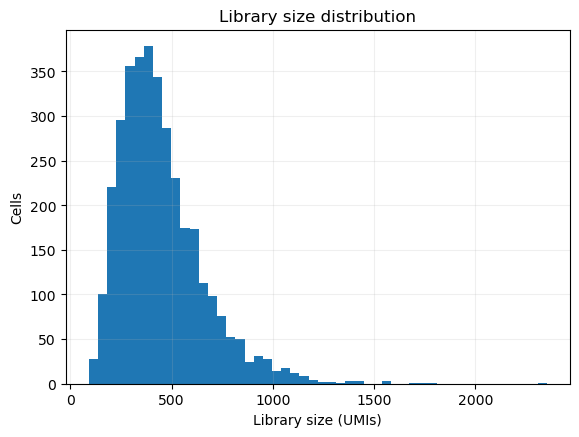

<Figure size 640x480 with 0 Axes>

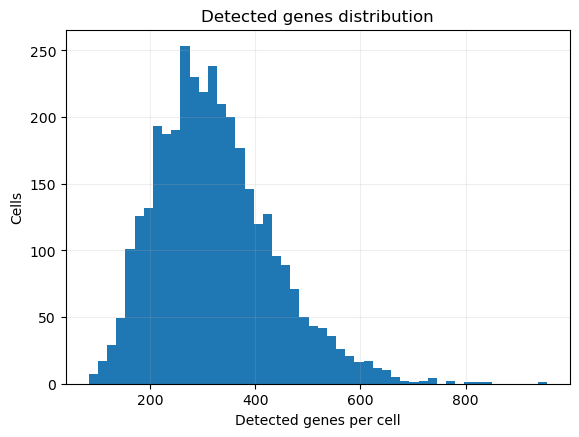

<Figure size 640x480 with 0 Axes>

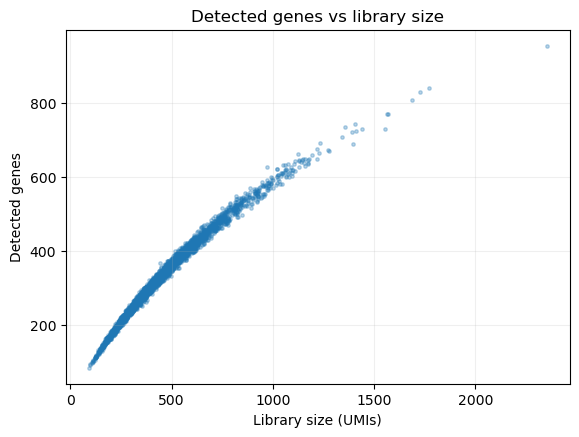

<Figure size 640x480 with 0 Axes>

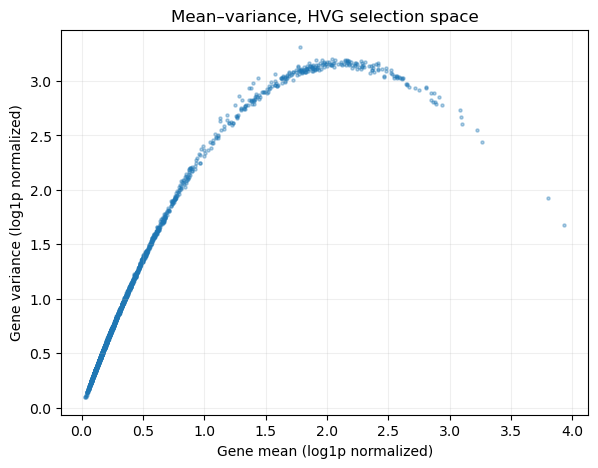

<Figure size 640x480 with 0 Axes>

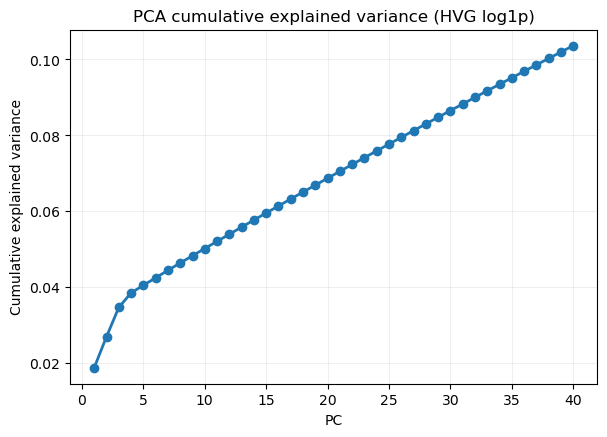

<Figure size 640x480 with 0 Axes>

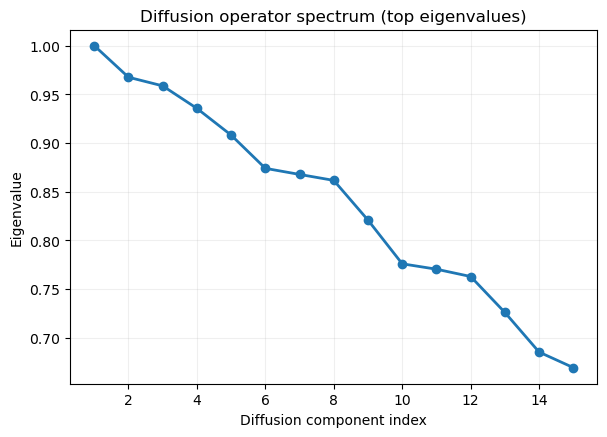

<Figure size 640x480 with 0 Axes>

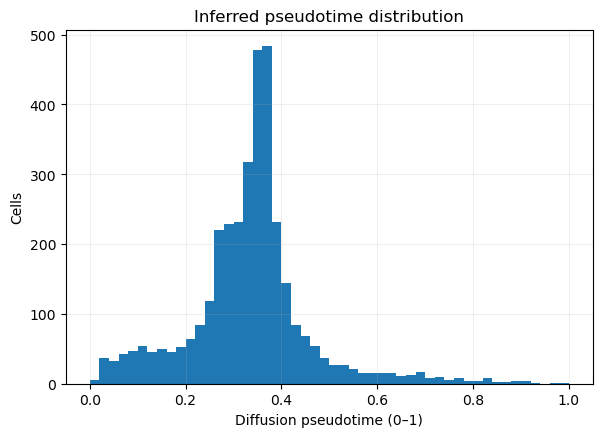

<Figure size 640x480 with 0 Axes>

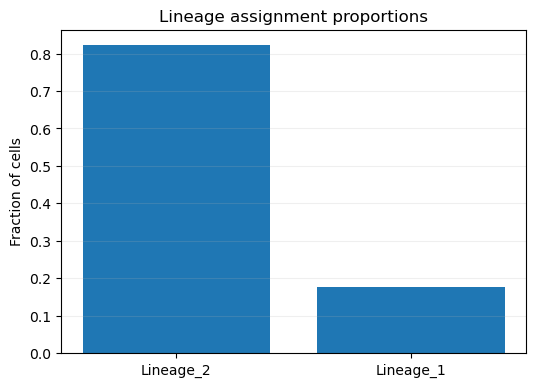

<Figure size 640x480 with 0 Axes>

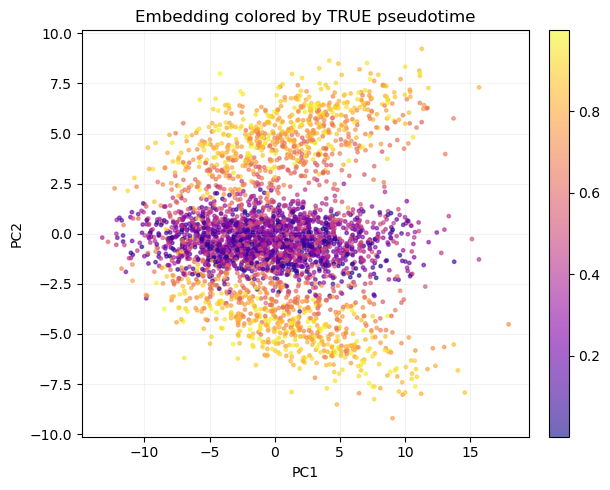

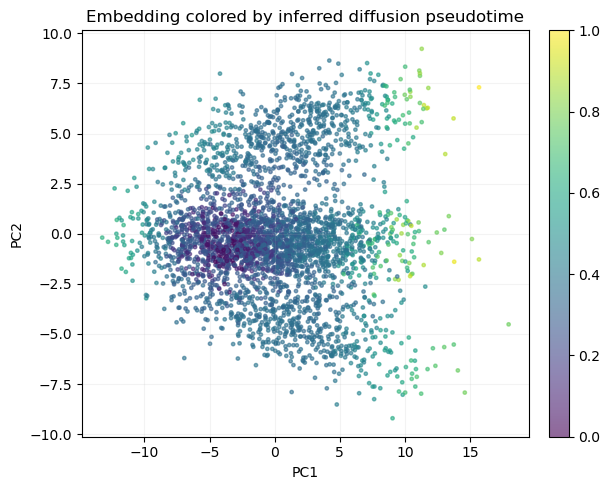

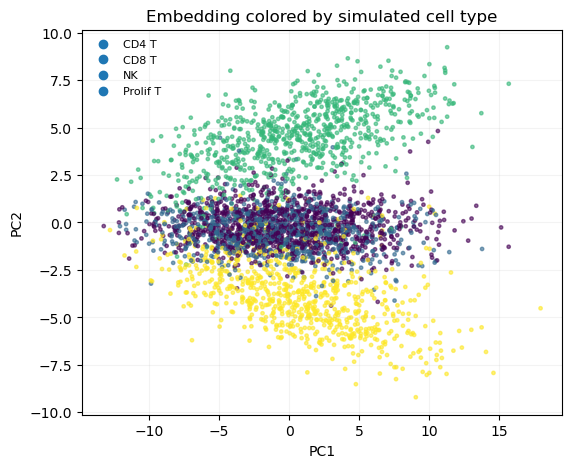

<Figure size 640x480 with 0 Axes>

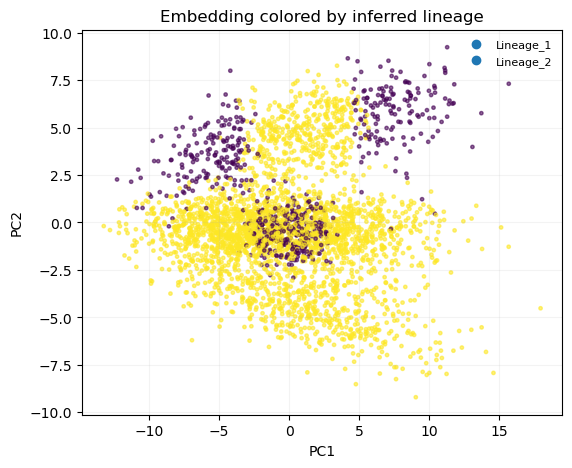

<Figure size 640x480 with 0 Axes>

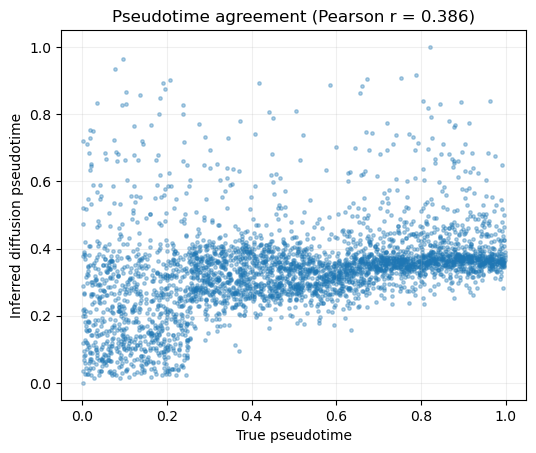

<Figure size 640x480 with 0 Axes>

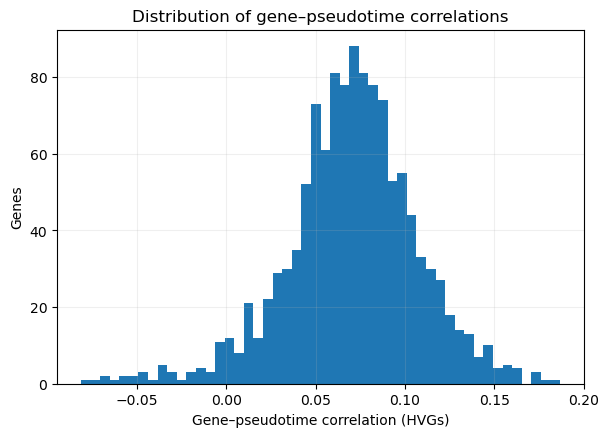

<Figure size 640x480 with 0 Axes>

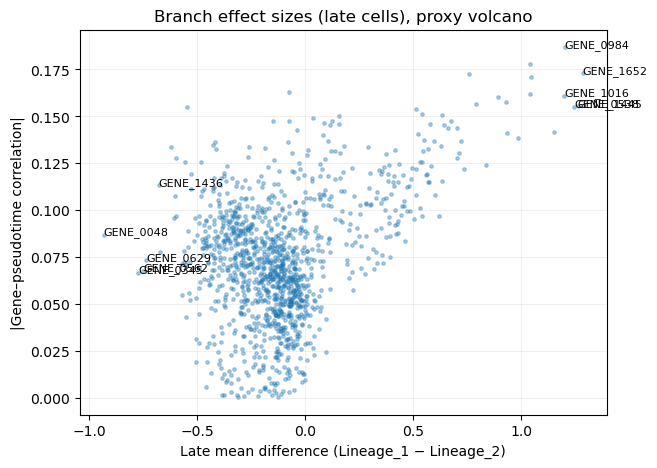

<Figure size 640x480 with 0 Axes>

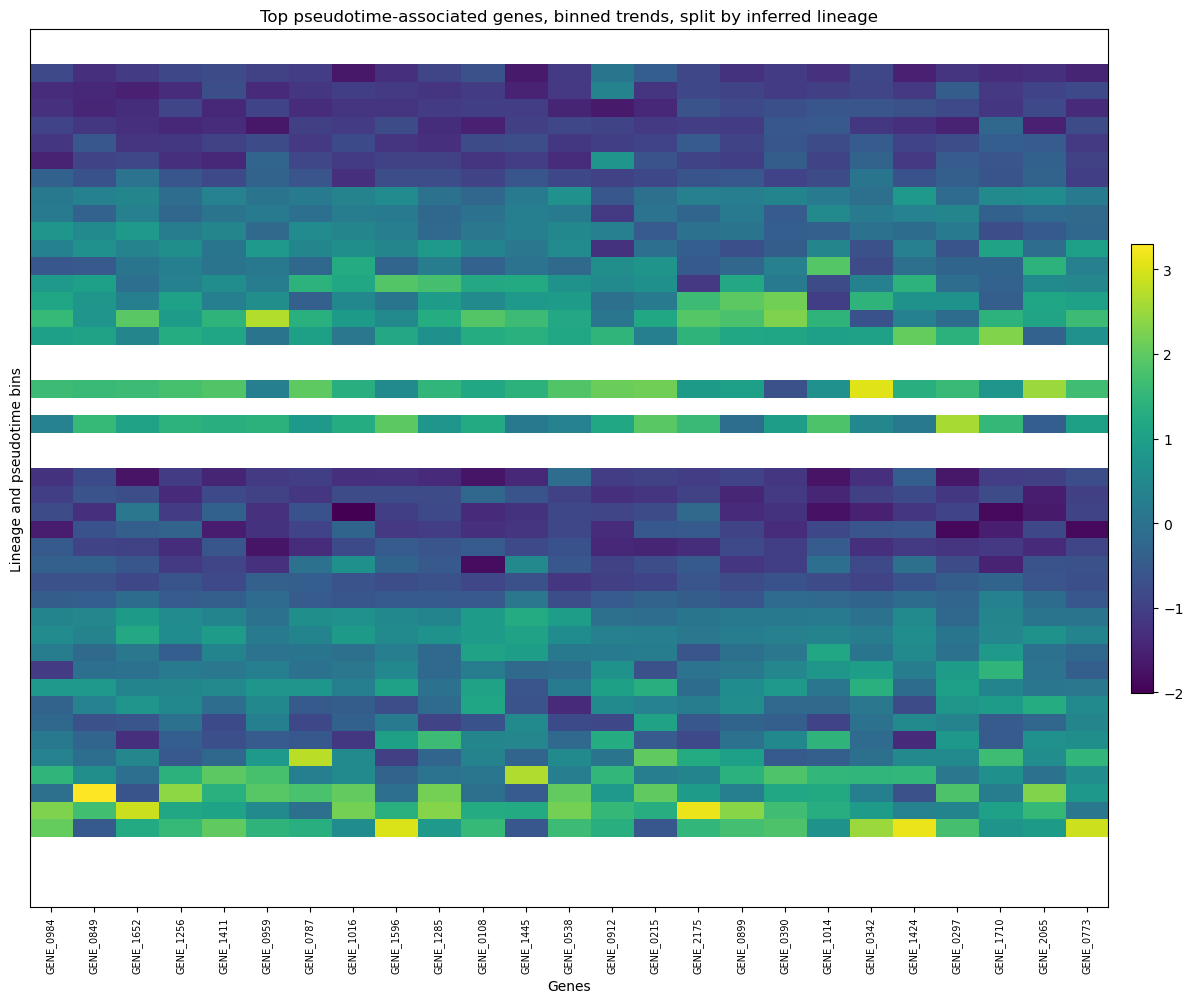

<Figure size 640x480 with 0 Axes>

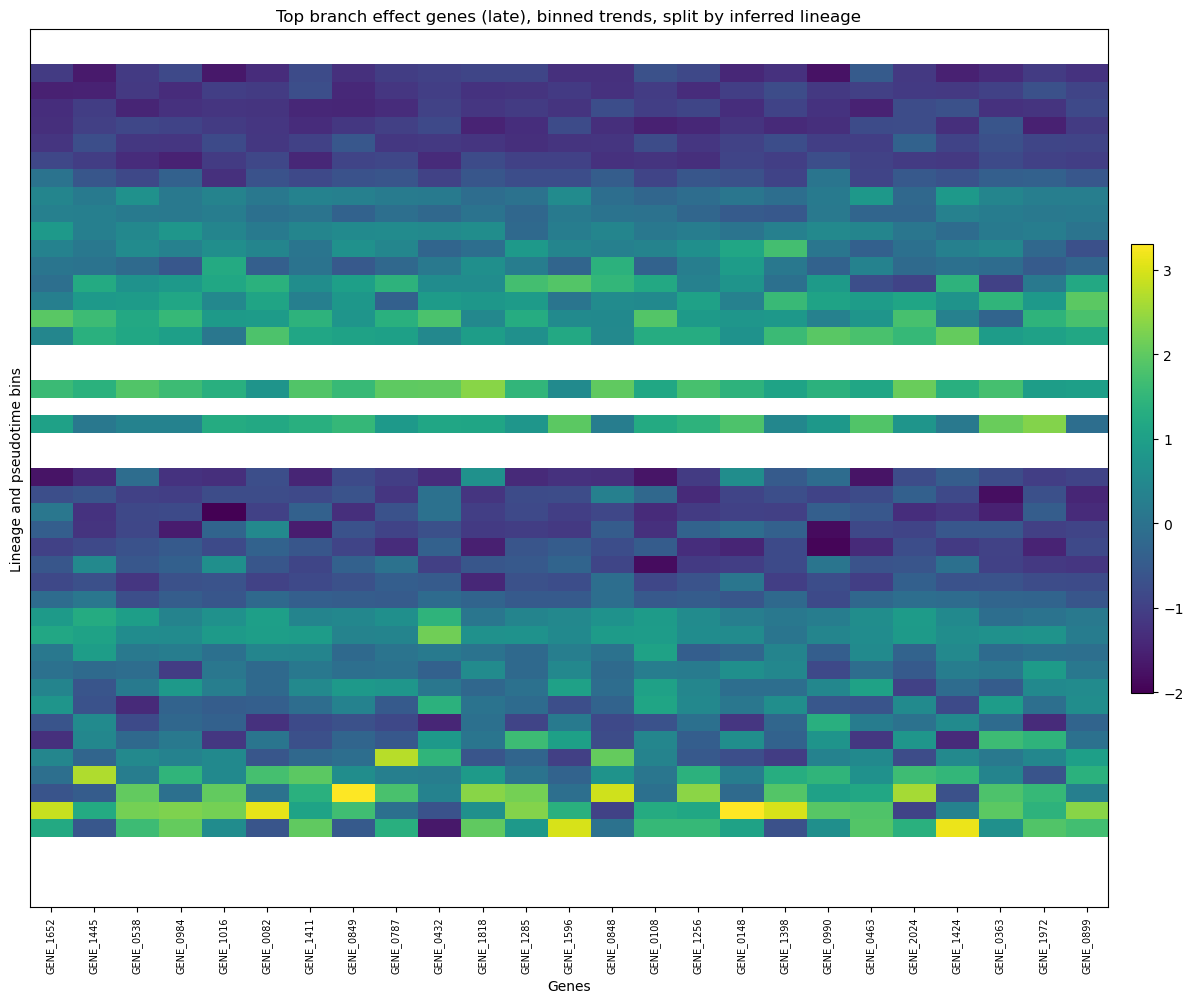

<Figure size 640x480 with 0 Axes>

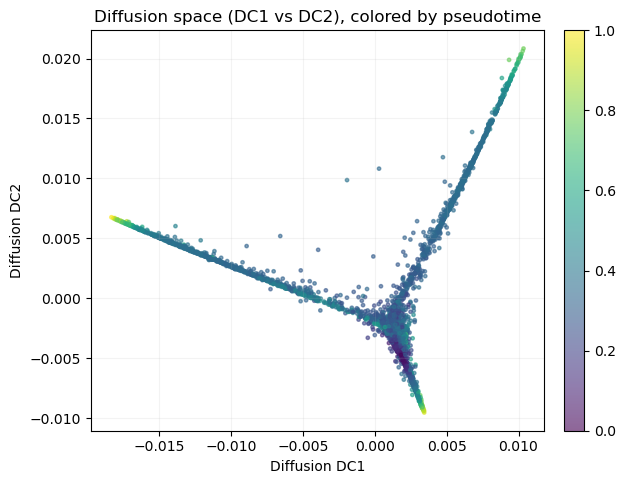

<Figure size 640x480 with 0 Axes>

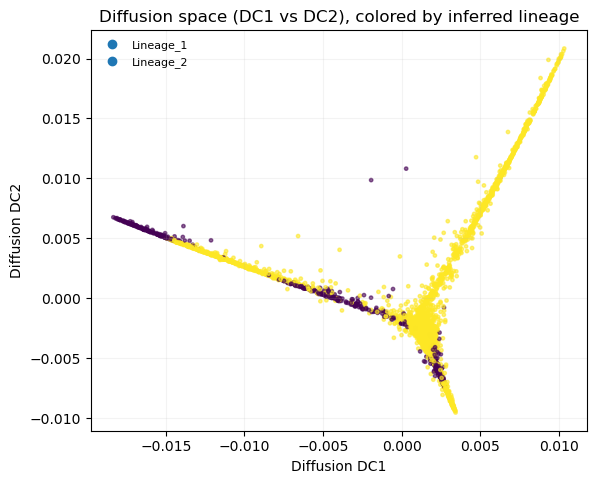

<Figure size 640x480 with 0 Axes>

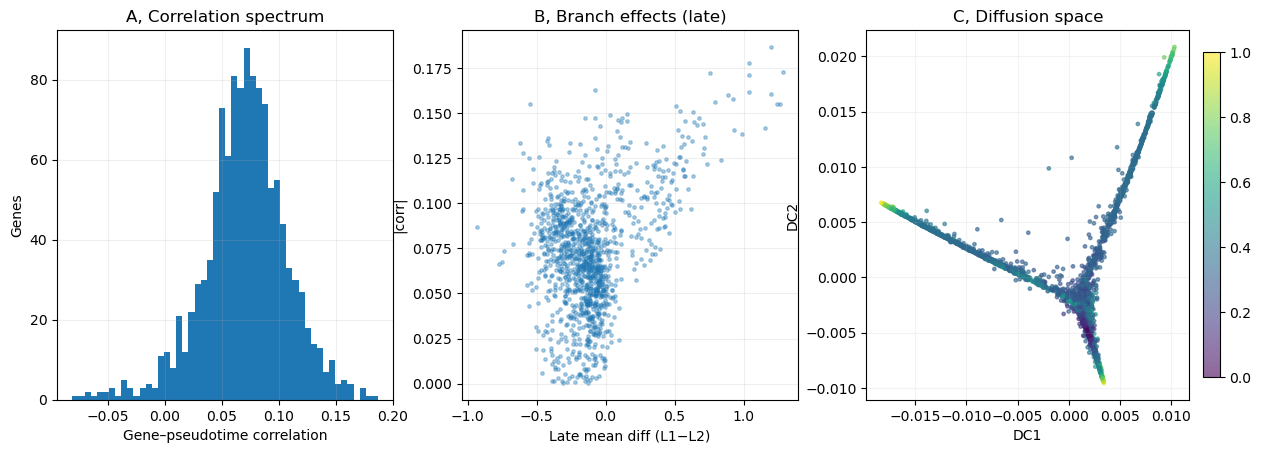

Continued analysis complete.
Figures written to: results_trajectory_sim_no_scanpy/figures
Tables written to: results_trajectory_sim_no_scanpy/tables
Key composites:
 - results_trajectory_sim_no_scanpy/figures/COMPOSITE_overview.png
 - results_trajectory_sim_no_scanpy/figures/COMPOSITE_gene_programs.png


In [27]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import os, math

%matplotlib inline

# Reuse output dirs if defined earlier
OUTDIR = globals().get("OUTDIR", "results_trajectory_sim_no_scanpy")
FIGDIR = globals().get("FIGDIR", os.path.join(OUTDIR, "figures"))
TABDIR = globals().get("TABDIR", os.path.join(OUTDIR, "tables"))
DATDIR = globals().get("DATDIR", os.path.join(OUTDIR, "data"))
for d in [OUTDIR, FIGDIR, TABDIR, DATDIR]:
    os.makedirs(d, exist_ok=True)

def savefig(path):
    plt.tight_layout()
    plt.show()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()

# 1) QC and basic dataset diagnostics

# Library size distribution, detected genes, sparsity
X_counts_csr = X_counts.tocsr() if sparse.issparse(X_counts) else sparse.csr_matrix(X_counts)

libsize = np.asarray(X_counts_csr.sum(axis=1)).reshape(-1)
detected = np.asarray((X_counts_csr > 0).sum(axis=1)).reshape(-1)
sparsity = 1.0 - (X_counts_csr.nnz / (X_counts_csr.shape[0] * X_counts_csr.shape[1]))

qc = pd.DataFrame({
    "library_size": libsize,
    "detected_genes": detected,
})
qc.to_csv(os.path.join(TABDIR, "qc_cell_metrics.csv"), index=False)

fig = plt.figure(figsize=(6.5,4.6))
plt.hist(libsize, bins=50)
plt.xlabel("Library size (UMIs)")
plt.ylabel("Cells")
plt.title("Library size distribution")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "qc_library_size_hist.png"))

fig = plt.figure(figsize=(6.5,4.6))
plt.hist(detected, bins=50)
plt.xlabel("Detected genes per cell")
plt.ylabel("Cells")
plt.title("Detected genes distribution")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "qc_detected_genes_hist.png"))

fig = plt.figure(figsize=(6.5,4.6))
plt.scatter(libsize, detected, s=6, alpha=0.3)
plt.xlabel("Library size (UMIs)")
plt.ylabel("Detected genes")
plt.title("Detected genes vs library size")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "qc_detected_vs_library.png"))

# 2) HVG mean–variance plot

# If df_hvg exists from previous cell, reuse; else compute quickly from X_log
if "df_hvg" not in globals():
    X_log_csr = X_log.tocsr()
    gene_mean = np.asarray(X_log_csr.mean(axis=0)).reshape(-1)
    gene_sq_mean = np.asarray(X_log_csr.multiply(X_log_csr).mean(axis=0)).reshape(-1)
    gene_var = np.clip(gene_sq_mean - gene_mean**2, 0, None)
    df_hvg = pd.DataFrame({"gene": np.arange(X_log_csr.shape[1]), "mean_log1p": gene_mean, "var_log1p": gene_var})

fig = plt.figure(figsize=(6.8,5.0))
plt.scatter(df_hvg["mean_log1p"], df_hvg["var_log1p"], s=5, alpha=0.35)
plt.xlabel("Gene mean (log1p normalized)")
plt.ylabel("Gene variance (log1p normalized)")
plt.title("Mean–variance, HVG selection space")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "hvg_mean_variance_scatter.png"))

# 3) PCA diagnostics

if "pca" in globals():
    var_ratio = pca.explained_variance_ratio_
    fig = plt.figure(figsize=(6.8,4.6))
    plt.plot(np.arange(1, len(var_ratio)+1), np.cumsum(var_ratio), marker="o", linewidth=2)
    plt.xlabel("PC")
    plt.ylabel("Cumulative explained variance")
    plt.title("PCA cumulative explained variance (HVG log1p)")
    plt.grid(True, alpha=0.2)
    plt.show()
    savefig(os.path.join(FIGDIR, "pca_cum_explained_variance.png"))

# 4) Diffusion map diagnostics

# Eigenvalues of diffusion operator (symmetric normalized)
fig = plt.figure(figsize=(6.8,4.6))
plt.plot(np.arange(1, len(evals)+1), evals, marker="o", linewidth=2)
plt.xlabel("Diffusion component index")
plt.ylabel("Eigenvalue")
plt.title("Diffusion operator spectrum (top eigenvalues)")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "diffusion_eigenvalues.png"))

# Check pseudotime distribution and lineage proportions
pt = obs["dpt_pseudotime"].values
fig = plt.figure(figsize=(6.8,4.6))
plt.hist(pt, bins=50)
plt.xlabel("Diffusion pseudotime (0–1)")
plt.ylabel("Cells")
plt.title("Inferred pseudotime distribution")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "pseudotime_hist.png"))

lin_counts = obs["inferred_lineage"].value_counts().rename_axis("lineage").reset_index(name="cells")
lin_counts["fraction"] = lin_counts["cells"] / lin_counts["cells"].sum()
lin_counts.to_csv(os.path.join(TABDIR, "lineage_counts.csv"), index=False)

fig = plt.figure(figsize=(6.0,4.2))
plt.bar(lin_counts["lineage"], lin_counts["fraction"])
plt.ylabel("Fraction of cells")
plt.title("Lineage assignment proportions")
plt.grid(True, axis="y", alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "lineage_proportions.png"))

# 5) Embedding plots (PCA as lightweight 2D embedding)

if "emb1" not in obs.columns:
    obs["emb1"] = Z[:, 0]
    obs["emb2"] = Z[:, 1]

def scatter_numeric(x, y, c, title, cmap, path):
    fig = plt.figure(figsize=(6.2,5.0))
    ax = plt.gca()
    sca = ax.scatter(x, y, c=c, s=6, alpha=0.6, cmap=cmap)
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    savefig(path)

def scatter_categorical(x, y, cat, title, path):
    cats = pd.Categorical(cat)
    codes = cats.codes
    fig = plt.figure(figsize=(6.2,5.0))
    ax = plt.gca()
    ax.scatter(x, y, c=codes, s=6, alpha=0.6)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    handles = [plt.Line2D([0],[0], marker="o", linestyle="", markersize=6, label=str(l))
               for l in cats.categories]
    ax.legend(handles=handles, frameon=False, loc="best", fontsize=8)
    plt.show()
    savefig(path)

scatter_numeric(
    obs["emb1"].values, obs["emb2"].values, obs["true_pseudotime"].values,
    "Embedding colored by TRUE pseudotime", "plasma",
    os.path.join(FIGDIR, "embed_true_pseudotime.png")
)
scatter_numeric(
    obs["emb1"].values, obs["emb2"].values, obs["dpt_pseudotime"].values,
    "Embedding colored by inferred diffusion pseudotime", "viridis",
    os.path.join(FIGDIR, "embed_inferred_pseudotime.png")
)
scatter_categorical(
    obs["emb1"].values, obs["emb2"].values, obs["true_cell_type"].values,
    "Embedding colored by simulated cell type",
    os.path.join(FIGDIR, "embed_true_cell_type.png")
)
scatter_categorical(
    obs["emb1"].values, obs["emb2"].values, obs["inferred_lineage"].values,
    "Embedding colored by inferred lineage",
    os.path.join(FIGDIR, "embed_inferred_lineage.png")
)

# 6) Pseudotime agreement (simulation audit)

r = float(np.corrcoef(obs["true_pseudotime"].values, obs["dpt_pseudotime"].values)[0, 1])
agree = pd.DataFrame([{"pearson_r_true_vs_inferred_pseudotime": r, "sparsity": float(sparsity)}])
agree.to_csv(os.path.join(TABDIR, "pseudotime_agreement_summary.csv"), index=False)

fig = plt.figure(figsize=(6.0,4.8))
plt.scatter(obs["true_pseudotime"], obs["dpt_pseudotime"], s=6, alpha=0.35)
plt.xlabel("True pseudotime")
plt.ylabel("Inferred diffusion pseudotime")
plt.title(f"Pseudotime agreement (Pearson r = {r:.3f})")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "pseudotime_agreement_scatter.png"))

# 7) Gene-level analysis visualizations

# 7.1 Correlation spectrum
fig = plt.figure(figsize=(6.8,4.6))
plt.hist(df_pt["corr_with_dpt"].values, bins=50)
plt.xlabel("Gene–pseudotime correlation (HVGs)")
plt.ylabel("Genes")
plt.title("Distribution of gene–pseudotime correlations")
plt.grid(True, alpha=0.2)
plt.show()
savefig(os.path.join(FIGDIR, "gene_pseudotime_corr_hist.png"))

# 7.2 Volcano-like plot for branch differences in late cells (effect size vs |corr|)
# (No p-values here, we keep it CPU-light and deterministic, effect sizes are still informative in simulation.)
fig = plt.figure(figsize=(6.8,5.0))
x = df_branch["late_mean_diff"].values
# reuse corr for HVGs by merging
corr_map = dict(zip(df_pt["gene"].values, df_pt["corr_with_dpt"].values))
y = np.array([abs(corr_map.get(g, 0.0)) for g in df_branch["gene"].values])
plt.scatter(x, y, s=6, alpha=0.35)
plt.xlabel("Late mean difference (Lineage_1 − Lineage_2)")
plt.ylabel("|Gene–pseudotime correlation|")
plt.title("Branch effect sizes (late cells), proxy volcano")
plt.grid(True, alpha=0.2)

# label a few extremes
for g in df_branch.head(5)["gene"].tolist() + df_branch.tail(5)["gene"].tolist():
    row = df_branch.loc[df_branch["gene"] == g].iloc[0]
    plt.text(row["late_mean_diff"], abs(corr_map.get(g, 0.0)), g, fontsize=8)
plt.show()
savefig(os.path.join(FIGDIR, "branch_effect_proxy_volcano.png"))

# 7.3 Heatmap of top genes across pseudotime bins, split by lineage
def pseudotime_binned_heatmap(X_log_hvg, genes, title, path, n_bins=30):
    pt = obs["dpt_pseudotime"].values
    lin = obs["inferred_lineage"].values
    gene_to_col = {g:i for i,g in enumerate(hvg_genes)}
    cols = [gene_to_col[g] for g in genes]
    M = X_log_hvg[:, cols]

    # bins
    bins = np.linspace(0, 1, n_bins+1)
    b = np.digitize(pt, bins) - 1
    b = np.clip(b, 0, n_bins-1)

    uniq_lin = sorted(pd.unique(lin))
    blocks = []
    ylabels = []
    for u in uniq_lin:
        mu = np.zeros((n_bins, len(cols)), dtype=float)
        for bi in range(n_bins):
            mask = (lin == u) & (b == bi)
            if mask.sum() < 5:
                mu[bi, :] = np.nan
            else:
                mu[bi, :] = M[mask].mean(axis=0)
        # z-score per gene for visualization
        mu_z = (mu - np.nanmean(mu, axis=0, keepdims=True)) / (np.nanstd(mu, axis=0, keepdims=True) + 1e-8)
        blocks.append(mu_z)
        ylabels += [f"{u} bin {i+1:02d}" for i in range(n_bins)]

    H = np.vstack(blocks)

    fig = plt.figure(figsize=(0.42*len(cols)+4.0, 0.18*H.shape[0]+2.4))
    ax = plt.gca()
    im = ax.imshow(H, aspect="auto", interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    ax.set_title(title)
    ax.set_xlabel("Genes")
    ax.set_ylabel("Lineage and pseudotime bins")
    ax.set_xticks(np.arange(len(genes)))
    ax.set_xticklabels(genes, rotation=90, fontsize=7)
    ax.set_yticks([])
    plt.show()
    savefig(path)

top_pt_genes = df_pt.head(25)["gene"].tolist()
pseudotime_binned_heatmap(
    X_hvg_log, top_pt_genes,
    "Top pseudotime-associated genes, binned trends, split by inferred lineage",
    os.path.join(FIGDIR, "heatmap_top_pseudotime_genes_binned.png"),
    n_bins=25
)

top_branch_genes = df_branch.head(25)["gene"].tolist()
pseudotime_binned_heatmap(
    X_hvg_log, top_branch_genes,
    "Top branch effect genes (late), binned trends, split by inferred lineage",
    os.path.join(FIGDIR, "heatmap_top_branch_genes_binned.png"),
    n_bins=25
)

# 8) Trajectory backbone visualization in diffusion space (2D)

# Plot diffusion components 1 vs 2 (Y columns 0,1 correspond to phi[:,1],phi[:,2])
fig = plt.figure(figsize=(6.4,5.2))
plt.scatter(Y[:,0], Y[:,1], c=obs["dpt_pseudotime"].values, s=6, alpha=0.6, cmap="viridis")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xlabel("Diffusion DC1")
plt.ylabel("Diffusion DC2")
plt.title("Diffusion space (DC1 vs DC2), colored by pseudotime")
plt.grid(True, alpha=0.15)
plt.show()
savefig(os.path.join(FIGDIR, "diffusion_space_dc1_dc2.png"))

fig = plt.figure(figsize=(6.4,5.2))
cats = pd.Categorical(obs["inferred_lineage"].values)
plt.scatter(Y[:,0], Y[:,1], c=cats.codes, s=6, alpha=0.6)
plt.xlabel("Diffusion DC1")
plt.ylabel("Diffusion DC2")
plt.title("Diffusion space (DC1 vs DC2), colored by inferred lineage")
plt.grid(True, alpha=0.15)
handles = [plt.Line2D([0],[0], marker="o", linestyle="", markersize=6, label=str(l)) for l in cats.categories]
plt.legend(handles=handles, frameon=False, loc="best", fontsize=8)
plt.show()
savefig(os.path.join(FIGDIR, "diffusion_space_lineage.png"))

# 9) Composite figures (with panels)

# Composite 1: trajectory overview (8 panels)
fig = plt.figure(figsize=(15.0,8.6))
gs = fig.add_gridspec(2,4, width_ratios=[1,1,1,1.05], height_ratios=[1,1])

axA = fig.add_subplot(gs[0,0])
sca = axA.scatter(obs["emb1"], obs["emb2"], c=obs["true_pseudotime"], s=6, alpha=0.6, cmap="plasma")
fig.colorbar(sca, ax=axA, fraction=0.046, pad=0.04)
axA.set_title("A, True pseudotime"); axA.set_xlabel("PC1"); axA.set_ylabel("PC2"); axA.grid(True, alpha=0.15)

axB = fig.add_subplot(gs[0,1])
cats = pd.Categorical(obs["true_cell_type"])
axB.scatter(obs["emb1"], obs["emb2"], c=cats.codes, s=6, alpha=0.6)
axB.set_title("B, Cell types"); axB.set_xlabel("PC1"); axB.set_ylabel("PC2"); axB.grid(True, alpha=0.15)
handles = [plt.Line2D([0],[0], marker="o", linestyle="", markersize=6, label=str(l)) for l in cats.categories]
axB.legend(handles=handles, frameon=False, loc="best", fontsize=8)

axC = fig.add_subplot(gs[0,2])
sca = axC.scatter(obs["emb1"], obs["emb2"], c=obs["dpt_pseudotime"], s=6, alpha=0.6, cmap="viridis")
fig.colorbar(sca, ax=axC, fraction=0.046, pad=0.04)
axC.set_title("C, Inferred pseudotime"); axC.set_xlabel("PC1"); axC.set_ylabel("PC2"); axC.grid(True, alpha=0.15)

axD = fig.add_subplot(gs[0,3])
cats = pd.Categorical(obs["inferred_lineage"])
axD.scatter(obs["emb1"], obs["emb2"], c=cats.codes, s=6, alpha=0.6)
axD.set_title("D, Inferred lineage"); axD.set_xlabel("PC1"); axD.set_ylabel("PC2"); axD.grid(True, alpha=0.15)
handles = [plt.Line2D([0],[0], marker="o", linestyle="", markersize=6, label=str(l)) for l in cats.categories]
axD.legend(handles=handles, frameon=False, loc="best", fontsize=8)

axE = fig.add_subplot(gs[1,0])
axE.hist(obs["library_size"], bins=45)
axE.set_title("E, Library size"); axE.set_xlabel("UMIs"); axE.set_ylabel("Cells"); axE.grid(True, alpha=0.2)

axF = fig.add_subplot(gs[1,1])
axF.scatter(obs["true_pseudotime"], obs["dpt_pseudotime"], s=6, alpha=0.35)
axF.set_title(f"F, Agreement r={r:.3f}")
axF.set_xlabel("True"); axF.set_ylabel("Inferred"); axF.grid(True, alpha=0.2)

axG = fig.add_subplot(gs[1,2])
axG.plot(np.arange(1, len(evals)+1), evals, marker="o", linewidth=2)
axG.set_title("G, Diffusion spectrum")
axG.set_xlabel("DC"); axG.set_ylabel("Eigenvalue"); axG.grid(True, alpha=0.2)

axH = fig.add_subplot(gs[1,3])
axH.hist(df_pt["corr_with_dpt"].values, bins=45)
axH.set_title("H, Gene–pseudotime corr")
axH.set_xlabel("Correlation"); axH.set_ylabel("Genes"); axH.grid(True, alpha=0.2)

fig.savefig(os.path.join(FIGDIR, "COMPOSITE_overview.png"), dpi=250, bbox_inches="tight")
fig.savefig(os.path.join(FIGDIR, "COMPOSITE_overview.pdf"), bbox_inches="tight")
plt.close(fig)

# Composite 2: gene programs (3 panels)
fig = plt.figure(figsize=(15.0,4.8))
gs = fig.add_gridspec(1,3, width_ratios=[1,1,1.05])

ax1 = fig.add_subplot(gs[0,0])
ax1.hist(df_pt["corr_with_dpt"].values, bins=50)
ax1.set_title("A, Correlation spectrum")
ax1.set_xlabel("Gene–pseudotime correlation"); ax1.set_ylabel("Genes"); ax1.grid(True, alpha=0.2)

ax2 = fig.add_subplot(gs[0,1])
x = df_branch["late_mean_diff"].values
y = np.array([abs(corr_map.get(g, 0.0)) for g in df_branch["gene"].values])
ax2.scatter(x, y, s=6, alpha=0.35)
ax2.set_title("B, Branch effects (late)")
ax2.set_xlabel("Late mean diff (L1−L2)"); ax2.set_ylabel("|corr|"); ax2.grid(True, alpha=0.2)

ax3 = fig.add_subplot(gs[0,2])
ax3.scatter(Y[:,0], Y[:,1], c=obs["dpt_pseudotime"].values, s=6, alpha=0.6, cmap="viridis")
cb = fig.colorbar(ax3.collections[0], ax=ax3, fraction=0.046, pad=0.04)
ax3.set_title("C, Diffusion space")
ax3.set_xlabel("DC1"); ax3.set_ylabel("DC2"); ax3.grid(True, alpha=0.15)
plt.show()
fig.savefig(os.path.join(FIGDIR, "COMPOSITE_gene_programs.png"), dpi=250, bbox_inches="tight")
fig.savefig(os.path.join(FIGDIR, "COMPOSITE_gene_programs.pdf"), bbox_inches="tight")
plt.close(fig)

# 10) Save a final summary table

final_summary = pd.DataFrame([{
    "n_cells": int(X_counts_csr.shape[0]),
    "n_genes_raw": int(X_counts_csr.shape[1]),
    "sparsity": float(sparsity),
    "median_library_size": float(np.median(libsize)),
    "median_detected_genes": float(np.median(detected)),
    "n_hvgs": int(len(hvg_genes)),
    "pearson_r_true_vs_inferred_pseudotime": float(r),
    "terminal_1_index": int(term1),
    "terminal_2_index": int(term2),
}])
final_summary.to_csv(os.path.join(TABDIR, "FINAL_summary.csv"), index=False)

print("Continued analysis complete.")
print("Figures written to:", FIGDIR)
print("Tables written to:", TABDIR)
print("Key composites:")
print(" -", os.path.join(FIGDIR, "COMPOSITE_overview.png"))
print(" -", os.path.join(FIGDIR, "COMPOSITE_gene_programs.png"))